# Transfer learning, and what the course adds up to

A new defect appears on Meridian's line on a Monday. By Friday there are forty
labelled photographs of it. Notebook 02's convolutional network needed a few
hundred images to reach the ceiling, so forty is not enough — and waiting six
months for more is not an answer, because the line is shipping now.

**Transfer learning** is the observation that a network trained on a related
task has already learned most of what the new one needs. The first layers
detect local contrast; nothing about that is specific to scratches.

Nothing is downloaded here. The "pre-trained" network is one trained earlier
in this notebook, which is also the honest way to see what transfer actually
depends on. Handout sections 10 and 11.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 tensorflow-cpu==2.21.0

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from wafer_data import (make_wafer_images, make_defect_types, make_rare_defect,
                        TRUE_IMAGE_SIZE, TRUE_DEFECT_TYPES,
                        TRUE_CLUSTER_CONTRAST, TRUE_GRADER_ERROR_RATE)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"
tf.config.experimental.enable_op_determinism()
S = TRUE_IMAGE_SIZE


def conv_net(seed=0, n_out=1, act="sigmoid"):
    keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(S, S, 1))
    x = layers.Conv2D(8, 3, activation="relu", padding="same", name="c1")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(16, 3, activation="relu", padding="same", name="c2")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalMaxPooling2D()(x)
    x = layers.Dense(16, activation="relu")(x)
    model = keras.Model(inputs, layers.Dense(n_out, activation=act)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy" if n_out == 1
                  else "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


X_rare, y_rare, _ = make_rare_defect(seed=10002, n_images=400)
X_rare_te, y_rare_te, t_rare_te = make_rare_defect(seed=10009, n_images=1500)
print(f"the new defect: {len(X_rare)} labelled images in hand, "
      f"{len(X_rare_te)} for testing")
print(f"ceiling on the test set: {(y_rare_te == t_rare_te).mean():.4f}")
print(f"its contrast is {TRUE_CLUSTER_CONTRAST} — fainter than a particle, "
      f"which is what makes it hard from few examples")

I0000 00:00:1787908627.791312   78626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787908628.973676   78626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


the new defect: 400 labelled images in hand, 1500 for testing
ceiling on the test set: 0.9847
its contrast is 0.24 — fainter than a particle, which is what makes it hard from few examples


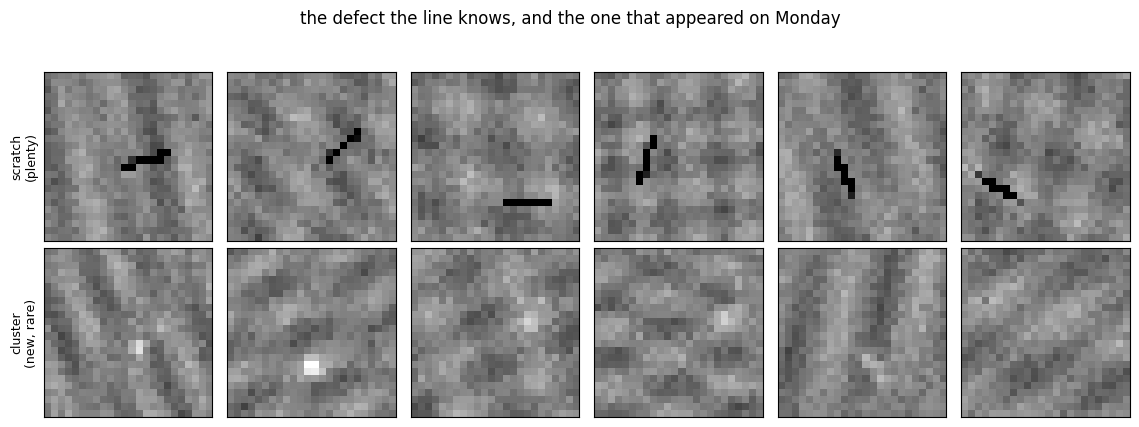

In [2]:
X_seen, y_seen, t_seen = make_wafer_images(seed=10001, n_images=600)
fig, axes = plt.subplots(2, 6, figsize=(11.5, 4.2))
for col in range(6):
    axes[0, col].imshow(X_seen[t_seen == 1][col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_rare[y_rare == 1][col], cmap="gray", vmin=0, vmax=1)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("scratch\n(plenty)", fontsize=9)
axes[1, 0].set_ylabel("cluster\n(new, rare)", fontsize=9)
fig.suptitle("the defect the line knows, and the one that appeared on Monday", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "rare_defect.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Pre-training on a task nobody actually wants solved

The source task matters more than anything else in transfer, so it is worth
choosing deliberately rather than reaching for whatever is lying around.

Grading dies pass/fail on scratches teaches **one** detector. Naming *which*
of three types is present — clean, scratch, particle — forces the early layers
to describe local structure in general: dark lines and bright blobs both.
Nobody at Meridian needs a defect-type classifier. It is built because of what
its early layers are forced to learn on the way.

In [3]:
X_type, y_type = make_defect_types(seed=10005, n_images=6000)
pretrained = conv_net(seed=0, n_out=3, act="softmax")
pretrained.fit(X_type[..., None], y_type, epochs=30, batch_size=64, verbose=0)
print(f"pre-training task ({', '.join(TRUE_DEFECT_TYPES)}): "
      f"{pretrained.evaluate(X_type[..., None], y_type, verbose=0)[1]:.4f}")
print("\nThis number is not a result. It is a receipt showing the source task")
print("was learned, which is the precondition for its features being useful.")

pre-training task (clean, scratch, particle): 0.9993

This number is not a result. It is a receipt showing the source task
was learned, which is the precondition for its features being useful.


## 3. Starting from those weights instead of from noise

In [4]:
def warm_started(n_few, seed, source=None, freeze=False):
    """A binary network whose convolutional kernels start from `source`."""
    model = conv_net(seed=seed)
    if source is not None:
        for name in ("c1", "c2"):
            model.get_layer(name).set_weights(source.get_layer(name).get_weights())
            model.get_layer(name).trainable = not freeze
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(X_rare[:n_few, ..., None], y_rare[:n_few], epochs=60,
              batch_size=16, verbose=0)
    return model.evaluate(X_rare_te[..., None], y_rare_te, verbose=0)[1]


rows = []
for n_few in (25, 50, 100, 200, 400):
    scratch = np.mean([warm_started(n_few, s) for s in range(2)])
    warm = np.mean([warm_started(n_few, s, pretrained) for s in range(2)])
    frozen = np.mean([warm_started(n_few, s, pretrained, freeze=True)
                      for s in range(2)])
    rows.append({"labelled images": n_few, "from scratch": scratch,
                 "warm-started": warm, "warm-started, frozen base": frozen,
                 "gain from warm start": warm - scratch})
transfer = pd.DataFrame(rows).set_index("labelled images")
transfer.round(4)

,from scratch,warm-started,"warm-started, frozen base",gain from warm start
labelled images,,,,
25,0.5100,0.5100,0.5000,0.0000
50,0.5707,0.6603,0.5273,0.0897
100,0.7220,0.8640,0.5390,0.1420
200,0.7270,0.8940,0.7150,0.1670
400,0.8447,0.7877,0.8727,-0.0570


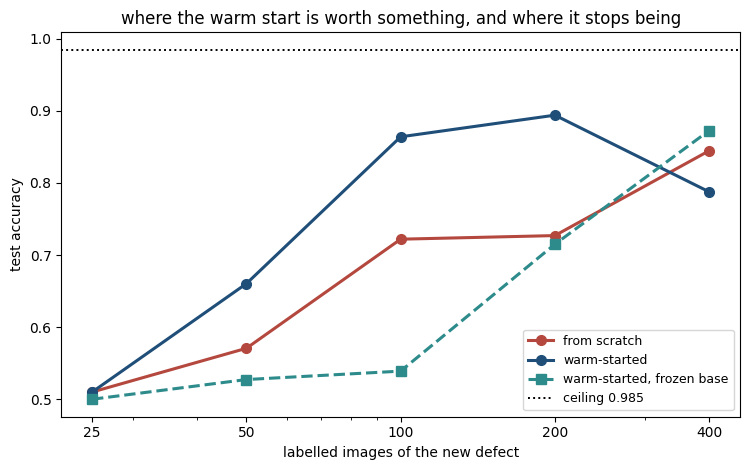

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for column, colour, style in (("from scratch", RUST, "o-"),
                              ("warm-started", BLUE, "o-"),
                              ("warm-started, frozen base", TEAL, "s--")):
    ax.plot(transfer.index, transfer[column], style, color=colour, lw=2.2,
            ms=7, label=column)
ax.axhline((y_rare_te == t_rare_te).mean(), color="k", ls=":", lw=1.4,
           label=f"ceiling {(y_rare_te == t_rare_te).mean():.3f}")
ax.set_xscale("log")
ax.set_xticks(transfer.index)
ax.set_xticklabels(transfer.index)
ax.set_xlabel("labelled images of the new defect")
ax.set_ylabel("test accuracy")
ax.legend(fontsize=9, loc="lower right")
ax.set_title("where the warm start is worth something, and where it stops being")
fig.tight_layout()
fig.savefig(FIGURES / "transfer_curve.png", dpi=150)
plt.show()

Read the `gain from warm start` column across the rows rather than at one
point, because it does not do what the slogan says.

**At 25 images nothing works.** From scratch and warm-started are both at
chance. There is not enough here to fit a head onto features, however good.

**Between 50 and 200 the warm start is worth 9 to 17 points.** This is the
band transfer exists for, and note that the gain *grows* across it rather than
shrinking — the warm start needs a few dozen examples before it can express
what it knows.

**By 400 it has stopped helping**, and in this run the warm-started model is
actually a little behind. The from-scratch network has now seen enough of the
new defect to learn its own features, and the borrowed ones are a constraint
rather than a head start.

So the honest shape is a *window*, not a monotone decline: too little data and
transfer has nothing to attach to, too much and it has nothing to add.

## 4. When transfer makes things worse

Transfer is routinely presented as free. It is not, and the failure has a name
— **negative transfer** — and a cause worth being able to predict.

Repeat the experiment with a source task chosen badly: pre-train only on
scratches, which are *dark lines*, and transfer to clusters, which are *bright
specks*. The low-level features are close to opposite in polarity.

In [6]:
X_scr, y_scr, _ = make_wafer_images(seed=10001, n_images=6000, defect="scratch")
wrong_source = conv_net(seed=0)
wrong_source.fit(X_scr[..., None], y_scr, epochs=30, batch_size=64, verbose=0)

comparison = []
for n_few in (50, 100, 200):
    comparison.append({
        "labelled images": n_few,
        "from scratch": np.mean([warm_started(n_few, s) for s in range(2)]),
        "from the typing task": np.mean(
            [warm_started(n_few, s, pretrained, freeze=True) for s in range(2)]),
        "from scratches only": np.mean(
            [warm_started(n_few, s, wrong_source, freeze=True) for s in range(2)])})
sources = pd.DataFrame(comparison).set_index("labelled images")
sources.round(4)

,from scratch,from the typing task,from scratches only
labelled images,,,
50,0.5707,0.5273,0.5150
100,0.7220,0.5390,0.5047
200,0.7270,0.7150,0.5350


Two things in this table, and the second is the one that was not planned.

**The badly chosen source is stuck at chance.** Frozen kernels trained only on
dark scratches are committed to reporting darkness where the new defect is
bright, and a frozen layer cannot change its mind. It never leaves 0.50 at any
sample size here.

**But freezing hurt the *good* source too.** At 50 and 100 images the frozen
typing features are also behind starting from noise, and they only pull level
by 200. Compare that with the unfrozen warm start in section 3, which was
ahead by 14 points at exactly 100 images. The features were useful; **freezing
them was the mistake**, not borrowing them.

So the rule is not "always pre-train", and it is not "freeze the base" either:

- **Transfer carries whatever the source task forced the network to learn, and
  nothing else.** Ask what the source task actually required before assuming
  its features are general.
- **Freezing is a bet that the borrowed features are already right.** It is
  cheap and it is safe only when the source task is close to the target. When
  in doubt, warm-start and leave everything trainable — that recovers from a
  bad source, and a frozen base cannot.

## 5. What the course adds up to

Ten lessons, and the wafer problem is a fair place to put them side by side —
with one twist that is the real point of the exercise.

Run every family on the **raw 576 pixels**. Then run the same families on
**four numbers** computed from each image by hand, using the contrast kernel
notebook 01 wrote down before anything was trained.

In [7]:
X_all, y_all, t_all = make_wafer_images(seed=10001, n_images=3000)
X_ev, y_ev, t_ev = make_wafer_images(seed=12345, n_images=2000)

contrast_kernel = np.array([[1., 1., 1.], [1., -8., 1.], [1., 1., 1.]])


def hand_features(images):
    """Four numbers per image, from notebook 01's hand-written kernel."""
    from scipy.signal import correlate2d
    out = np.empty((len(images), 4))
    for i, image in enumerate(images):
        response = correlate2d(image, contrast_kernel, mode="valid")
        out[i] = [response.max(), response.min(),
                  response.std(), np.abs(response).max()]
    return out


F_all, F_ev = hand_features(X_all), hand_features(X_ev)
print(f"raw pixels: {X_all.reshape(len(X_all), -1).shape[1]} features")
print(f"by hand   : {F_all.shape[1]} features")

families = {
    "logistic regression (L3, L4)": LogisticRegression(max_iter=3000),
    "k-nearest neighbours (L6)": KNeighborsClassifier(15),
    "support vector machine (L6)": SVC(),
    "random forest (L7)": RandomForestClassifier(300, random_state=0, n_jobs=-1),
}

results = []
for name, model in families.items():
    pipe = make_pipeline(StandardScaler(), model)
    pipe.fit(X_all.reshape(len(X_all), -1), y_all)
    raw = pipe.score(X_ev.reshape(len(X_ev), -1), y_ev)
    pipe2 = make_pipeline(StandardScaler(), model)
    pipe2.fit(F_all, y_all)
    engineered = pipe2.score(F_ev, y_ev)
    results.append({"family": name, "on raw pixels": raw,
                    "on 4 hand-made features": engineered})
pd.DataFrame(results).set_index("family").round(4)

raw pixels: 576 features
by hand   : 4 features


,on raw pixels,on 4 hand-made features
family,,
"logistic regression (L3, L4)",0.8905,0.9800
k-nearest neighbours (L6),0.4970,0.9800
support vector machine (L6),0.9660,0.9800
random forest (L7),0.9780,0.9795


In [8]:
def keras_score(build, n_out=1, act="sigmoid"):
    m = build(seed=0, n_out=n_out, act=act)
    m.fit(X_all[..., None], y_all, epochs=40, batch_size=64, verbose=0)
    return m.evaluate(X_ev[..., None], y_ev, verbose=0)[1], m.count_params()


def dense_net(seed=0, n_out=1, act="sigmoid"):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.Input(shape=(S, S, 1)), layers.Flatten(),
                          layers.Dense(256, activation="relu"),
                          layers.Dense(256, activation="relu"),
                          layers.Dense(n_out, activation=act)])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
              metrics=["accuracy"])
    return m


dense_acc, dense_p = keras_score(dense_net)
conv_acc, conv_p = keras_score(conv_net)
tree_hand = make_pipeline(StandardScaler(),
                          RandomForestClassifier(300, random_state=0, n_jobs=-1))
tree_hand.fit(F_all, y_all)

print(f"ceiling on this test set          : {(y_ev == t_ev).mean():.4f}")
print(f"dense network, raw pixels (L9)    : {dense_acc:.4f}   {dense_p:,} parameters")
print(f"convolutional network, raw (L10)  : {conv_acc:.4f}   {conv_p:,} parameters")
print(f"random forest on 4 hand features  : {tree_hand.score(F_ev, y_ev):.4f}")

ceiling on this test set          : 0.9800
dense network, raw pixels (L9)    : 0.7430   213,761 parameters
convolutional network, raw (L10)  : 0.9800   1,537 parameters
random forest on 4 hand features  : 0.9795


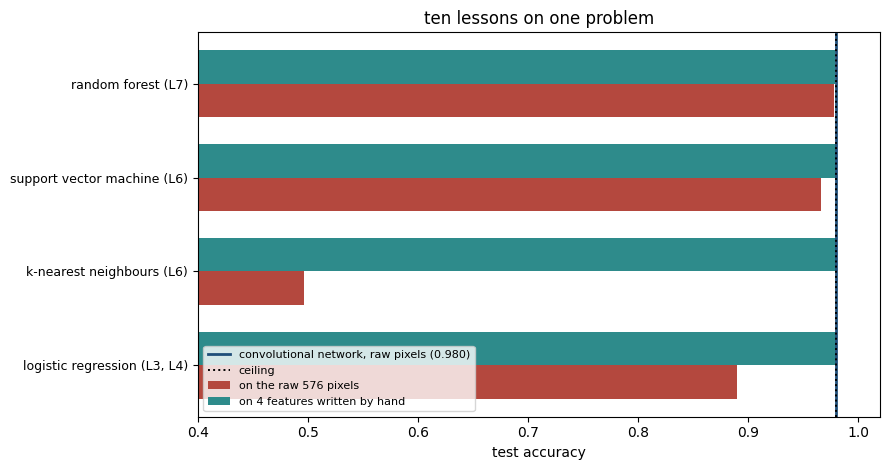

In [9]:
summary = pd.DataFrame(results).set_index("family")
fig, ax = plt.subplots(figsize=(9.0, 4.8))
spots = np.arange(len(summary))
ax.barh(spots - 0.18, summary["on raw pixels"], 0.36, color=RUST,
        label="on the raw 576 pixels")
ax.barh(spots + 0.18, summary["on 4 hand-made features"], 0.36, color=TEAL,
        label="on 4 features written by hand")
ax.axvline(conv_acc, color=BLUE, lw=2.0,
           label=f"convolutional network, raw pixels ({conv_acc:.3f})")
ax.axvline((y_ev == t_ev).mean(), color="k", ls=":", lw=1.4, label="ceiling")
ax.set_yticks(spots)
ax.set_yticklabels(summary.index, fontsize=9)
ax.set_xlim(0.4, 1.02)
ax.set_xlabel("test accuracy")
ax.legend(fontsize=8, loc="lower left")
ax.set_title("ten lessons on one problem")
fig.tight_layout()
fig.savefig(FIGURES / "family_comparison.png", dpi=150)
plt.show()

This table is the course, and it is not the table this section was written to
produce. Read it carefully, because the expected result did not happen.

**The random forest reaches 0.9780 on the raw 576 pixels** — level with the
convolutional network, and it knows nothing whatever about which pixel is next
to which. The support vector machine gets 0.9660. Neither of them is
"struggling", and any summary of this lesson that says classical methods
cannot handle images has just been contradicted by its own experiment.

The reason is that a tree does not need to know about adjacency to answer this
particular question. A defect drives *some* pixel to an unusual value, and a
forest of 300 trees, each splitting on individual pixels, can cover enough of
them to notice. That is its own inductive bias — "the answer depends on a few
features crossing thresholds" — and it happens to suit this task.

**Two families do fail, and instructively.** k-nearest neighbours collapses to
0.4970, because Euclidean distance over 576 pixels is dominated by the smooth
background variation and the seven-pixel defect contributes almost nothing to
it — lesson 6's curse of dimensionality, exactly. And **lesson 9's dense
network, at 0.7430, is the second worst thing on the table**, well behind plain
logistic regression at 0.8905. Flexibility without a matching assumption is
not an advantage.

**Four hand-written numbers put every classical family at the ceiling.** Those
four came from a 3×3 kernel written down in notebook 01 before anything was
trained, by thinking about what a defect *is*. The convolutional network,
given only raw pixels, found an equivalent feature by itself.

That is the honest summary of the last ten weeks, and it is about
representations rather than about models. A model turns a representation into
a decision, and the representation usually matters more than the model does.
Classical methods make you build it; convolutional networks learn it, paying
in data and compute. Neither is a default — which is why lesson 9 found a
hidden layer worth 39 points on one problem and 0.09 on another, why this
lesson's convolution is worth 24 points over a dense network here, and why a
random forest given nothing but raw pixels was within two thousandths of it.

## Summary

- Transfer learning warm-starts a new task from a related one's weights, and
  its value is concentrated where labels are scarce.
- **The source task is the whole game.** Features transfer only if the source
  forced the network to learn them.
- Negative transfer is real: a badly chosen source, frozen, is worse than
  starting from noise. If unsure, do not freeze.
- Across ten lessons, on one problem: the convolutional network and a plain
  random forest both reach about 0.978 on raw pixels, k-nearest neighbours
  collapses to chance, and lesson 9's dense network lands behind logistic
  regression. Given four hand-written features every classical family is at
  the ceiling. **The representation is doing most of the work throughout** —
  the only question is who builds it.